In [4]:
import random
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings

warnings.filterwarnings('ignore')

In [5]:
# ============================================
# 1. SETUP AND DATA LOADING
# ============================================

seed = 42
random.seed(seed)
np.random.seed(seed)
print(f"Global random seeds set to {seed}")

# Data Loading and Preprocessing
df = pd.read_csv('SU.csv', parse_dates=['Date'])
df = df.set_index('Date').sort_index()
df['SU_Close'] = df['SU_Close'].ffill()

# Extract target column and split data
test_size = 30
train_series = df[:-test_size]['SU_Close']
test_series = df[-test_size:]['SU_Close']

print(f"Training data: {len(train_series)} days")
print(f"Test data: {len(test_series)} days")


Global random seeds set to 42
Training data: 2781 days
Test data: 30 days


In [6]:
# ============================================
# 2. ARIMA COMPONENT - USER INPUT PARAMETERS
# ============================================

print("\n" + "="*60)
print("ARIMA COMPONENT - USER INPUT PARAMETERS")
print("="*60)

# Ask user for ARIMA parameters
print("\nPlease enter the ARIMA parameters from your previous ARIMA run:")
print("(These should be the values you got from your ARIMA-only code)")

# Get user input with validation
while True:
    try:
        p = int(input("Enter AR parameter p: "))
        if p < 0:
            print("p must be >= 0. Please try again.")
            continue
        break
    except ValueError:
        print("Please enter a valid integer for p.")

while True:
    try:
        d = int(input("Enter differencing parameter d: "))
        if d < 0:
            print("d must be >= 0. Please try again.")
            continue
        break
    except ValueError:
        print("Please enter a valid integer for d.")

while True:
    try:
        q = int(input("Enter MA parameter q: "))
        if q < 0:
            print("q must be >= 0. Please try again.")
            continue
        break
    except ValueError:
        print("Please enter a valid integer for q.")

print(f"\nUsing ARIMA({p}, {d}, {q}) as provided by user")
print(f"Note: No grid search will be performed for ARIMA parameters.")


ARIMA COMPONENT - USER INPUT PARAMETERS

Please enter the ARIMA parameters from your previous ARIMA run:
(These should be the values you got from your ARIMA-only code)

Using ARIMA(3, 1, 3) as provided by user
Note: No grid search will be performed for ARIMA parameters.


In [7]:
# ============================================
# 3. FIT ARIMA WITH USER PARAMETERS
# ============================================

print("\n" + "="*60)
print("FITTING ARIMA WITH USER-PROVIDED PARAMETERS")
print("="*60)

try:
    # Fit ARIMA on training data with user-provided parameters
    arima_model = ARIMA(train_series, order=(p, d, q))
    arima_fit = arima_model.fit()
    
    # Get ARIMA predictions and residuals
    arima_train_pred = arima_fit.fittedvalues
    arima_residuals = train_series - arima_train_pred
    arima_residuals.iloc[0] = 0  # Fix first residual
    arima_residuals = arima_residuals.dropna()
    
    print(f"\nARIMA({p},{d},{q}) successfully fitted to training data")
    print(f"AIC: {arima_fit.aic:.2f}")
    print(f"BIC: {arima_fit.bic:.2f}")
    print(f"Log Likelihood: {arima_fit.llf:.2f}")
    
    # Display ARIMA coefficients if available
    if len(arima_fit.params) > 0:
        print("\nInitial ARIMA Model Coefficients:")
        param_names = arima_fit.param_names
        param_values = arima_fit.params
        param_stderrs = arima_fit.bse
        param_pvalues = arima_fit.pvalues
        
        print(f"{'Parameter':<15} {'Coefficient':<15} {'Std Error':<15} {'z':<15} {'P>|z|':<15}")
        print("-" * 75)
        
        for name, value, stderr, pval in zip(param_names, param_values, param_stderrs, param_pvalues):
            # Calculate z-statistic
            z_stat = value / stderr if stderr != 0 else 0
            print(f"{name:<15} {value:<15.6f} {stderr:<15.6f} {z_stat:<15.6f} {pval:<15.6f}")
    
    print(f"\nARIMA residuals calculated")
    print(f"ARIMA residuals stats - Mean: {arima_residuals.mean():.4f}, Std: {arima_residuals.std():.4f}")
    print(f"ARIMA residuals saved")
    
except Exception as e:
    print(f"\nError fitting ARIMA({p},{d},{q}): {str(e)}")
    print("\nPlease check your parameters and try again.")
    print("Common issues:")
    print("  1. p or q too high for the available data")
    print("  2. Non-stationary series (d may need adjustment)")
    print("  3. Invalid parameter combination")
    exit(1)


FITTING ARIMA WITH USER-PROVIDED PARAMETERS

ARIMA(3,1,3) successfully fitted to training data
AIC: 7761.28
BIC: 7802.79
Log Likelihood: -3873.64

Initial ARIMA Model Coefficients:
Parameter       Coefficient     Std Error       z               P>|z|          
---------------------------------------------------------------------------
ar.L1           0.203282        0.064532        3.150101        0.001632       
ar.L2           -0.430175       0.043019        -9.999694       0.000000       
ar.L3           0.827149        0.060679        13.631518       0.000000       
ma.L1           -0.253853       0.058079        -4.370796       0.000012       
ma.L2           0.399363        0.039001        10.239790       0.000000       
ma.L3           -0.850841       0.052133        -16.320586      0.000000       
sigma2          0.950153        0.019613        48.445673       0.000000       

ARIMA residuals calculated
ARIMA residuals stats - Mean: 0.0088, Std: 0.9748
ARIMA residuals saved


In [8]:
# ============================================
# 4. XGBOOST COMPONENT FOR RESIDUALS (NO SCALER)
# ============================================

def create_sliding_windows(series, n_lags, n_future_steps):
    """Create sliding windows for time series data - NO SCALING"""
    X, y = [], []
    for i in range(len(series) - n_lags - n_future_steps + 1):
        X.append(series.iloc[i:i + n_lags].values)
        y.append(series.iloc[i + n_lags:i + n_lags + n_future_steps].values)
    return np.array(X), np.array(y)

In [9]:
# ==============================================================================
# 5. HYPERPARAMETER TUNING FOR RESIDUAL XGBOOST (70/30 HOLD-OUT, NO SCALER)
# ==============================================================================

print("\n" + "="*60)
print("HYPERPARAMETER TUNING FOR RESIDUAL XGBOOST (70/30 HOLD-OUT, NO SCALER)")
print("="*60)

# Define hyperparameter grid (same as original XGBoost grid)
hyperparameter_grid = {
    'n_lags': [22, 66, 132],
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

print(f"Hyperparameter grid to test:")
print(f"  n_lags: {hyperparameter_grid['n_lags']}")
print(f"  n_estimators: {hyperparameter_grid['n_estimators']}")
print(f"  learning_rate: {hyperparameter_grid['learning_rate']}")
print(f"  max_depth: {hyperparameter_grid['max_depth']}")

total_combinations = (len(hyperparameter_grid['n_lags']) * 
                      len(hyperparameter_grid['n_estimators']) * 
                      len(hyperparameter_grid['learning_rate']) * 
                      len(hyperparameter_grid['max_depth']))
print(f"Total combinations: {total_combinations}")

# Split residuals into train (70%) and validation (30%) sets
val_ratio = 0.3
split_idx = int(len(arima_residuals) * (1 - val_ratio))

train_residuals = arima_residuals.iloc[:split_idx]
val_residuals = arima_residuals.iloc[split_idx:]

print(f"\nResiduals split:")
print(f"  Training residuals: {len(train_residuals)} points ({100*(1-val_ratio):.0f}%)")
print(f"  Validation residuals: {len(val_residuals)} points ({100*val_ratio:.0f}%)")
print(f"  Training date range: {train_residuals.index[0].date()} to {train_residuals.index[-1].date()}")
print(f"  Validation date range: {val_residuals.index[0].date()} to {val_residuals.index[-1].date()}")

# Store results
all_results = []
best_val_rmse = float('inf')
best_hyperparams = None

print("\nStarting hyperparameter tuning for residual XGBoost (NO SCALER)...")

n_future_steps_per_block_val = 5  # Fixed 5-day forecasting horizon

for n_lags in hyperparameter_grid['n_lags']:
    for n_estimators in hyperparameter_grid['n_estimators']:
        for learning_rate in hyperparameter_grid['learning_rate']:
            for max_depth in hyperparameter_grid['max_depth']:
                
                print(f"\nTesting: n_lags={n_lags}, n_estimators={n_estimators}, lr={learning_rate}, max_depth={max_depth}")
                
                # Create sliding windows for residuals - NO SCALING
                X_train_res, y_train_res = create_sliding_windows(train_residuals, n_lags, n_future_steps_per_block_val)
                X_val_res, y_val_res = create_sliding_windows(val_residuals, n_lags, n_future_steps_per_block_val)
                
                # Check if we have enough data
                if len(X_train_res) == 0 or len(X_val_res) == 0:
                    print(f"  Skipped: Not enough data for windows (train={len(X_train_res)}, val={len(X_val_res)})")
                    continue
                
                # Train XGBoost model on residuals - NO SCALING
                try:
                    model = MultiOutputRegressor(
                        xgb.XGBRegressor(
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            max_depth=max_depth,
                            objective='reg:squarederror',
                            random_state=seed,
                            n_jobs=-1
                        ),
                        n_jobs=-1
                    )
                    
                    model.fit(X_train_res, y_train_res)
                    
                    # Make predictions on validation set
                    y_val_pred = model.predict(X_val_res)
                    
                    # Calculate RMSE
                    val_rmse = np.sqrt(mean_squared_error(y_val_res, y_val_pred))
                    
                    print(f"  Validation RMSE: {val_rmse:.6f}")
                    
                    # Store results
                    all_results.append({
                        'n_lags': n_lags,
                        'n_estimators': n_estimators,
                        'learning_rate': learning_rate,
                        'max_depth': max_depth,
                        'val_rmse': val_rmse,
                        'train_samples': len(X_train_res),
                        'val_samples': len(X_val_res)
                    })
                    
                    # Update best hyperparameters
                    if val_rmse < best_val_rmse:
                        best_val_rmse = val_rmse
                        best_hyperparams = {
                            'n_lags': n_lags,
                            'n_estimators': n_estimators,
                            'learning_rate': learning_rate,
                            'max_depth': max_depth
                        }
                        
                except Exception as e:
                    print(f"  Error: {str(e)}")
                    continue

# Display results
print("\n" + "="*60)
print("HYPERPARAMETER TUNING RESULTS FOR RESIDUAL XGBOOST (NO SCALER)")
print("="*60)

# Convert to DataFrame for nice display
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('val_rmse').reset_index(drop=True)

print("\nAll Results (sorted by Validation RMSE):")
print(f"{'n_lags':<8} {'n_estimators':<12} {'learning_rate':<12} {'max_depth':<10} {'Val RMSE':<12} {'Train Samples':<15} {'Val Samples':<12}")
print("-" * 85)

for _, row in results_df.iterrows():
    print(f"{row['n_lags']:<8} {row['n_estimators']:<12} {row['learning_rate']:<12.3f} {row['max_depth']:<10} "
          f"{row['val_rmse']:<12.6f} {row['train_samples']:<15} {row['val_samples']:<12}")

# Select best hyperparameters
print(f"\n{'='*60}")
print(f"BEST HYPERPARAMETERS SELECTED FOR RESIDUAL XGBOOST:")
print(f"{'='*60}")

best_n_lags = best_hyperparams['n_lags']
best_n_estimators = best_hyperparams['n_estimators']
best_learning_rate = best_hyperparams['learning_rate']
best_max_depth = best_hyperparams['max_depth']

print(f"  n_lags:          {best_n_lags}")
print(f"  n_estimators:    {best_n_estimators}")
print(f"  learning_rate:   {best_learning_rate}")
print(f"  max_depth:       {best_max_depth}")
print(f"  Validation RMSE: {best_val_rmse:.6f} (original scale - NO SCALER USED)")


HYPERPARAMETER TUNING FOR RESIDUAL XGBOOST (70/30 HOLD-OUT, NO SCALER)
Hyperparameter grid to test:
  n_lags: [22, 66, 132]
  n_estimators: [100, 200]
  learning_rate: [0.01, 0.1, 0.2]
  max_depth: [3, 5, 7]
Total combinations: 54

Residuals split:
  Training residuals: 1946 points (70%)
  Validation residuals: 835 points (30%)
  Training date range: 2008-01-02 to 2015-08-12
  Validation date range: 2015-08-13 to 2018-11-14

Starting hyperparameter tuning for residual XGBoost (NO SCALER)...

Testing: n_lags=22, n_estimators=100, lr=0.01, max_depth=3
  Validation RMSE: 0.932079

Testing: n_lags=22, n_estimators=100, lr=0.01, max_depth=5
  Validation RMSE: 0.936111

Testing: n_lags=22, n_estimators=100, lr=0.01, max_depth=7
  Validation RMSE: 0.939262

Testing: n_lags=22, n_estimators=100, lr=0.1, max_depth=3
  Validation RMSE: 0.946493

Testing: n_lags=22, n_estimators=100, lr=0.1, max_depth=5
  Validation RMSE: 0.962838

Testing: n_lags=22, n_estimators=100, lr=0.1, max_depth=7
  Vali

In [10]:
# ============================================
# 6. HYBRID ARIMA-XGBOOST RECURSIVE FORECASTING (NO SCALER)
# ============================================

print("\n" + "="*60)
print("HYBRID ARIMA-XGBOOST RECURSIVE FORECASTING (NO SCALER)")
print(f"Using ARIMA({p},{d},{q}) from user input")
print(f"Using tuned parameters: n_lags={best_n_lags}, n_estimators={best_n_estimators}, "
      f"learning_rate={best_learning_rate}, max_depth={best_max_depth}")
print("="*60)

n_future_steps_per_block_val = 5
num_test_blocks = len(test_series) // n_future_steps_per_block_val

print(f"Test blocks to forecast: {num_test_blocks} (5 days each)")
print(f"Total test days to forecast: {num_test_blocks * n_future_steps_per_block_val}")

# Store predictions and actuals
all_predictions = []
all_actuals = []
block_details = []

# Start with initial training data
current_train = train_series.copy()
current_residuals = arima_residuals.copy()

print(f"\nMaking {num_test_blocks} rolling forecasts (5 days each)...")
print(f"Initial training data: {len(current_train)} days\n")

for block in range(num_test_blocks):
    print("\n" + "-" * 60)
    print(f"BLOCK {block + 1}/{num_test_blocks}")
    print("-" * 60)
    
    # Get actual values for this block
    start_idx = block * n_future_steps_per_block_val
    end_idx = (block + 1) * n_future_steps_per_block_val
    actual_block = test_series.iloc[start_idx:end_idx]
    
    print(f"Training size: {len(current_train)} days")
    print(f"Forecasting test days: {start_idx + 1} to {end_idx}")
    print(f"Test dates: {actual_block.index[0].date()} to {actual_block.index[-1].date()}")
    
    # ============================================
    # STEP 1: ARIMA FORECASTING WITH DETAILED OUTPUT
    # ============================================
    print("\n[1] ARIMA Forecasting:")
    print(f"Fitting ARIMA({p},{d},{q}) model...")
    arima_current = ARIMA(current_train, order=(p, d, q))
    arima_fit_current = arima_current.fit()
    arima_forecast = arima_fit_current.forecast(steps=n_future_steps_per_block_val)
    
    print(f"ARIMA forecast: {arima_forecast.values.round(2)}")
    
    # ============================================
    # PRINT ARIMA COEFFICIENTS AND STATISTICS FOR THIS BLOCK
    # ============================================
    print("\n" + "="*40)
    print(f"ARIMA MODEL COEFFICIENTS - BLOCK {block + 1}")
    print("="*40)
    
    # Get the coefficients and statistics
    if len(arima_fit_current.params) > 0:
        param_names = arima_fit_current.param_names
        param_values = arima_fit_current.params
        param_stderrs = arima_fit_current.bse
        param_pvalues = arima_fit_current.pvalues
        
        print(f"{'Parameter':<15} {'Coefficient':<15} {'Std Error':<15} {'z':<15} {'P>|z|':<15}")
        print("-" * 75)
        
        for name, value, stderr, pval in zip(param_names, param_values, param_stderrs, param_pvalues):
            # Calculate z-statistic
            z_stat = value / stderr if stderr != 0 else 0
            print(f"{name:<15} {value:<15.6f} {stderr:<15.6f} {z_stat:<15.6f} {pval:<15.6f}")
        
        # Print statistical significance markers
        print("\nStatistical Significance:")
        print("  * p < 0.001: Highly significant (***)")
        print("  * p < 0.01: Very significant (**)")
        print("  * p < 0.05: Significant (*)")
        print("  * p < 0.1: Marginally significant (.)")
        
        print("\nSignificant Coefficients (p < 0.05):")
        significant_found = False
        for name, value, pval in zip(param_names, param_values, param_pvalues):
            if pval < 0.05:
                significance_marker = "***" if pval < 0.001 else "**" if pval < 0.01 else "*"
                print(f"  {name}: {value:.6f} {significance_marker}")
                significant_found = True
        if not significant_found:
            print("  No coefficients are statistically significant at p < 0.05")
    
    # Additional model statistics
    print(f"\nModel Statistics - Block {block + 1}:")
    print(f"  Log Likelihood: {arima_fit_current.llf:.4f}")
    print(f"  AIC: {arima_fit_current.aic:.4f}")
    print(f"  BIC: {arima_fit_current.bic:.4f}")
    print(f"  HQIC: {arima_fit_current.hqic:.4f}")
    print(f"  Sigma² (error variance): {arima_fit_current.params[-1]:.6f}")
    
    # Convergence status
    converged = arima_fit_current.mle_retvals.get('converged', True)
    print(f"  Convergence status: {'Converged' if converged else 'Not Converged'}")
    
    # Model diagnostics
    print(f"\nModel Fit Diagnostics:")
    print(f"  Number of observations: {arima_fit_current.nobs}")
    print(f"  Degrees of freedom: {arima_fit_current.df_model}")
    print(f"  Residual degrees of freedom: {arima_fit_current.df_resid}")
    
    # ============================================
    # END SECTION
    # ============================================
    
    # Get current ARIMA residuals
    arima_train_pred_current = arima_fit_current.fittedvalues
    current_residuals = current_train - arima_train_pred_current
    current_residuals.iloc[0] = 0
    current_residuals = current_residuals.dropna()
    
    # ============================================
    # STEP 2: XGBOOST RESIDUAL FORECASTING (NO SCALER)
    # ============================================
    print("\n[2] XGBoost Residual Forecasting (NO SCALER):")
    
    # Create sliding windows for current residuals - NO SCALING
    X_res_current, y_res_current = create_sliding_windows(current_residuals, best_n_lags, n_future_steps_per_block_val)
    
    if len(X_res_current) > 0:
        print(f"Residual sequences available: {len(X_res_current)}")
        
        # Train XGBoost on current residuals - NO SCALING
        print("Training XGBoost on current residuals (raw values)...")
        xgb_model_current = MultiOutputRegressor(
            xgb.XGBRegressor(
                n_estimators=best_n_estimators,
                learning_rate=best_learning_rate,
                max_depth=best_max_depth,
                objective='reg:squarederror',
                random_state=seed,
                n_jobs=-1
            ),
            n_jobs=-1
        )
        
        xgb_model_current.fit(X_res_current, y_res_current)
        
        # Get the last n_lags residuals for prediction
        last_residuals = current_residuals.iloc[-best_n_lags:].values.reshape(1, -1)
        
        # Predict residuals with XGBoost - NO INVERSE TRANSFORM NEEDED (no scaling used)
        xgb_residual_pred = xgb_model_current.predict(last_residuals).flatten()
        
        print(f"XGBoost residual forecast: {xgb_residual_pred.round(2)}")
    else:
        xgb_residual_pred = np.zeros(n_future_steps_per_block_val)
        print(f"XGBoost residual forecast: {xgb_residual_pred.round(2)} (zeros - insufficient data)")
    
    # ============================================
    # STEP 3: COMBINE ARIMA AND XGBOOST PREDICTIONS
    # ============================================
    print("\n[3] Combining ARIMA and XGBoost forecasts:")
    hybrid_forecast = arima_forecast.values + xgb_residual_pred
    
    # Print detailed predictions and actuals
    print("\nDetailed Predictions vs Actuals:")
    print(f"{'Day':^4} {'Date':^12} {'ARIMA':^12} {'XGB Res':^12} {'Hybrid':^12} {'Actual':^12} {'Error':^12} {'% Error':^10}")
    print("-" * 90)
    
    for i in range(len(hybrid_forecast)):
        day_num = start_idx + i + 1
        date_str = actual_block.index[i].strftime('%Y-%m-%d')
        arima_val = arima_forecast.values[i]
        xgb_res_val = xgb_residual_pred[i]
        hybrid_val = hybrid_forecast[i]
        actual_val = actual_block.values[i]
        error = actual_val - hybrid_val
        pct_error = (error / actual_val) * 100 if actual_val != 0 else 0
        
        print(f"{day_num:^4} {date_str:^12} {arima_val:^12.2f} {xgb_res_val:^12.2f} "
              f"{hybrid_val:^12.2f} {actual_val:^12.2f} "
              f"{error:^12.2f} {pct_error:^10.2f}%")
    
    # Store results
    all_predictions.extend(hybrid_forecast)
    all_actuals.extend(actual_block.values)
    
    # Calculate block performance
    block_rmse = np.sqrt(mean_squared_error(actual_block.values, hybrid_forecast))
    block_mae = mean_absolute_error(actual_block.values, hybrid_forecast)
    
    # Store block details including ARIMA coefficients
    block_details.append({
        'block': block + 1,
        'training_size': len(current_train),
        'start_date': actual_block.index[0],
        'end_date': actual_block.index[-1],
        'rmse': block_rmse,
        'mae': block_mae,
        'predictions': hybrid_forecast.copy(),
        'actuals': actual_block.values.copy(),
        'arima_predictions': arima_forecast.values.copy(),
        'xgb_residuals': xgb_residual_pred.copy(),
        'arima_coefficients': arima_fit_current.params.to_dict() if hasattr(arima_fit_current.params, 'to_dict') else dict(zip(arima_fit_current.param_names, arima_fit_current.params)),
        'arima_pvalues': arima_fit_current.pvalues.to_dict() if hasattr(arima_fit_current.pvalues, 'to_dict') else dict(zip(arima_fit_current.param_names, arima_fit_current.pvalues)),
        'arima_aic': arima_fit_current.aic,
        'arima_bic': arima_fit_current.bic
    })
    
    print("\nBlock Performance Summary:")
    print(f"  RMSE: {block_rmse:.2f}")
    print(f"  MAE:  {block_mae:.2f}")
    print(f"  Average Absolute % Error: {np.mean(np.abs(actual_block.values - hybrid_forecast) / actual_block.values * 100):.2f}%")
    
    # Add actuals to training for next block (if not last block)
    if block < num_test_blocks - 1:
        current_train = pd.concat([current_train, actual_block])
        print(f"\n✓ Added {len(actual_block)} actual days to training data for next block")
    else:
        print("\n✓ Final block completed - no more data to add")

# Convert to arrays
predictions = np.array(all_predictions)
actuals = np.array(all_actuals)


HYBRID ARIMA-XGBOOST RECURSIVE FORECASTING (NO SCALER)
Using ARIMA(3,1,3) from user input
Using tuned parameters: n_lags=132, n_estimators=100, learning_rate=0.01, max_depth=3
Test blocks to forecast: 6 (5 days each)
Total test days to forecast: 30

Making 6 rolling forecasts (5 days each)...
Initial training data: 2781 days


------------------------------------------------------------
BLOCK 1/6
------------------------------------------------------------
Training size: 2781 days
Forecasting test days: 1 to 5
Test dates: 2018-11-15 to 2018-11-21

[1] ARIMA Forecasting:
Fitting ARIMA(3,1,3) model...
ARIMA forecast: [63.43 63.47 63.55 63.47 63.44]

ARIMA MODEL COEFFICIENTS - BLOCK 1
Parameter       Coefficient     Std Error       z               P>|z|          
---------------------------------------------------------------------------
ar.L1           0.203282        0.064532        3.150101        0.001632       
ar.L2           -0.430175       0.043019        -9.999694       0.000000

In [11]:
# ============================================
# 7. PERFORMANCE EVALUATION
# ============================================

print("\n" + "="*60)
print("PERFORMANCE EVALUATION")
print("="*60)

# Calculate overall metrics
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)

print(f"Overall Performance on {len(actuals)}-day test set:")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  MAPE: {np.mean(np.abs((actuals - predictions) / actuals)) * 100:.2f}%")

# Print block-by-block summary
print("\n" + "-"*60)
print("BLOCK-BY-BLOCK PERFORMANCE SUMMARY")
print("-"*60)
print(f"{'Block':^6} {'Train Days':^12} {'Date Range':^24} {'RMSE':^10} {'MAE':^10}")
print("-"*60)

for block_info in block_details:
    date_range = f"{block_info['start_date'].strftime('%m/%d')} - {block_info['end_date'].strftime('%m/%d')}"
    print(f"{block_info['block']:^6} {block_info['training_size']:^12} {date_range:^24} "
          f"{block_info['rmse']:^10.2f} {block_info['mae']:^10.2f}")

# Print ARIMA coefficients evolution across blocks
print("\n" + "="*60)
print("ARIMA COEFFICIENTS EVOLUTION ACROSS BLOCKS")
print("="*60)

# Extract all unique parameter names across blocks
all_param_names = set()
for block_info in block_details:
    if 'arima_coefficients' in block_info:
        all_param_names.update(block_info['arima_coefficients'].keys())

all_param_names = sorted(list(all_param_names))

if all_param_names:
    print(f"\nCoefficient values across blocks:")
    print(f"{'Parameter':<15} " + " ".join([f"Block {i+1}".center(15) for i in range(len(block_details))]))
    print("-" * (15 + 15 * len(block_details)))
    
    for param in all_param_names:
        row = f"{param:<15} "
        for block_info in block_details:
            if 'arima_coefficients' in block_info and param in block_info['arima_coefficients']:
                row += f"{block_info['arima_coefficients'][param]:<15.4f}"
            else:
                row += f"{'N/A':<15}"
        print(row)
    
    print(f"\nP-values across blocks (significance):")
    print(f"{'Parameter':<15} " + " ".join([f"Block {i+1}".center(15) for i in range(len(block_details))]))
    print("-" * (15 + 15 * len(block_details)))
    
    for param in all_param_names:
        row = f"{param:<15} "
        for block_info in block_details:
            if 'arima_pvalues' in block_info and param in block_info['arima_pvalues']:
                pval = block_info['arima_pvalues'][param]
                # Add significance markers
                if pval < 0.001:
                    marker = "***"
                elif pval < 0.01:
                    marker = "**"
                elif pval < 0.05:
                    marker = "*"
                elif pval < 0.1:
                    marker = "."
                else:
                    marker = ""
                row += f"{pval:<10.4f}{marker:<5}"
            else:
                row += f"{'N/A':<15}"
        print(row)

# Calculate cumulative performance
print("\n" + "="*60)
print("CUMULATIVE PERFORMANCE BY HORIZON")
print("="*60)

print(f"\nTotal test days: {len(actuals)}")
print("\nCumulative Performance (from Day 1):")
print(f"{'Horizon':^10} {'Days':^10} {'RMSE':^12} {'MAE':^12}")
print("-"*50)

for horizon in [5, 10, 15, 20, 25, 30]:
    if horizon <= len(actuals):
        # Take first h days and calculate directly
        actuals_h = actuals[:horizon]
        preds_h = predictions[:horizon]
        
        rmse_h = np.sqrt(mean_squared_error(actuals_h, preds_h))
        mae_h = mean_absolute_error(actuals_h, preds_h)
        
        print(f"{horizon:^10} {'1-' + str(horizon):^10} {rmse_h:^12.2f} {mae_h:^12.2f}")

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual': actuals,
    'ARIMA_XGBoost_Predicted': predictions
}, index=test_series.iloc[:len(actuals)].index)

# Save results
comparison_df.to_csv('arima_xgboost.csv', index=True)
print(f"\n✓ Predictions saved to 'arima_xgboost.csv'")


PERFORMANCE EVALUATION
Overall Performance on 30-day test set:
  RMSE: 1.65
  MAE:  1.35
  MAPE: 2.22%

------------------------------------------------------------
BLOCK-BY-BLOCK PERFORMANCE SUMMARY
------------------------------------------------------------
Block   Train Days         Date Range           RMSE       MAE    
------------------------------------------------------------
  1        2781          11/15 - 11/21          0.54       0.45   
  2        2786          11/22 - 11/28          0.80       0.64   
  3        2791          11/29 - 12/05          1.16       1.00   
  4        2796          12/06 - 12/12          2.15       1.97   
  5        2801          12/13 - 12/19          2.29       2.09   
  6        2806          12/20 - 12/28          2.04       1.95   

ARIMA COEFFICIENTS EVOLUTION ACROSS BLOCKS

Coefficient values across blocks:
Parameter           Block 1         Block 2         Block 3         Block 4         Block 5         Block 6    
-----------------


VISUALIZATION


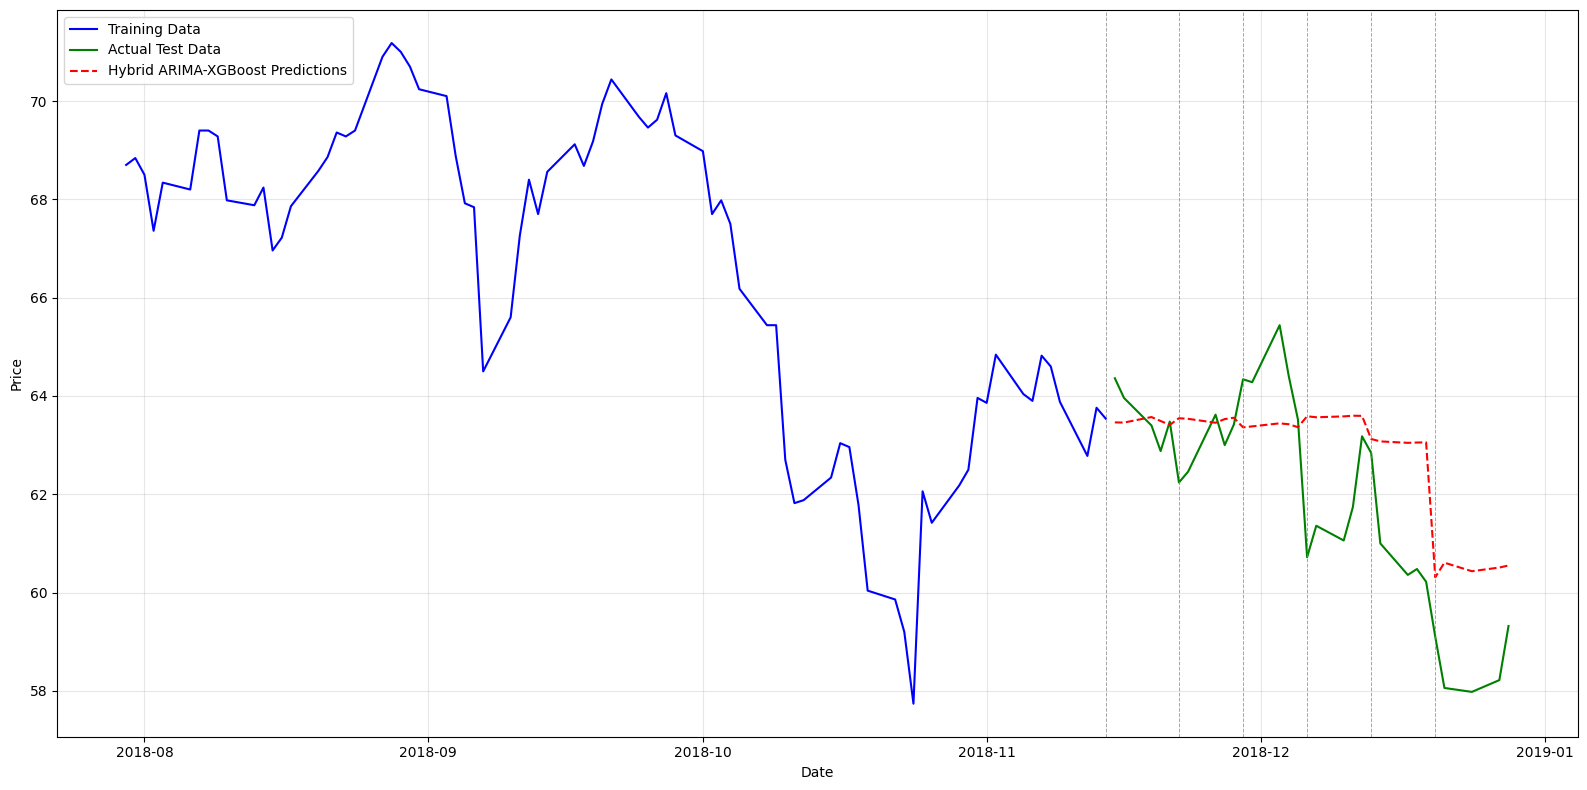

In [12]:
# ============================================
# 8. VISUALIZATION
# ============================================

print("\n" + "="*60)
print("VISUALIZATION")
print("="*60)

# Determine date range for last 5 months
end_date_plot = test_series.index.max()
start_date_plot = end_date_plot - pd.DateOffset(months=5)

# Filter data for plotting
train_data_plot = train_series[train_series.index >= start_date_plot]
actual_test_data_plot = test_series[test_series.index >= start_date_plot]
predicted_data_plot = comparison_df[comparison_df.index >= start_date_plot]

# Create plot
plt.figure(figsize=(16, 8))

# Plot training data
plt.plot(train_data_plot.index, train_data_plot.values, 
         label='Training Data', color='blue', linewidth=1.5)

# Plot actual test data
plt.plot(actual_test_data_plot.index, actual_test_data_plot.values, 
         label='Actual Test Data', color='green', linewidth=1.5)

# Plot hybrid predictions
plt.plot(predicted_data_plot.index, predicted_data_plot['ARIMA_XGBoost_Predicted'], 
         label='Hybrid ARIMA-XGBoost Predictions', color='red', linestyle='--', linewidth=1.5)

# Add vertical line for train-test split
plt.axvline(x=train_series.index[-1], color='gray', 
            linestyle='--', linewidth=0.7, alpha=0.7)

# Add block boundaries
for i in range(1, num_test_blocks):
    block_boundary = test_series.index[i * n_future_steps_per_block_val]
    plt.axvline(x=block_boundary, color='gray', linestyle='--', 
                alpha=0.7, linewidth=0.7)

plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# ============================================
# 9. FINAL SUMMARY
# ============================================

print(f"\n{'='*60}")
print("HYBRID ARIMA-XGBOOST FORECASTING COMPLETE (NO SCALER)")
print(f"{'='*60}")

print(f"\nModel Configuration:")
print(f"  ARIMA: ({p},{d},{q}) - from user input")
print(f"  XGBoost (tuned on residuals, no scaler): n_lags={best_n_lags}, "
      f"n_estimators={best_n_estimators}, learning_rate={best_learning_rate}, max_depth={best_max_depth}")

print(f"\nForecasting Strategy:")
print(f"  - Recursive retraining with {n_future_steps_per_block_val}-day blocks")
print(f"  - {num_test_blocks} blocks forecasted ({len(actuals)} days total)")
print(f"  - Hybrid = ARIMA_forecast + XGBoost_residual_forecast")
print(f"  - NO SCALER USED - working with raw values only")

print(f"\nARIMA Analysis:")
print(f"  - Model refitted for each of {num_test_blocks} blocks")
print(f"  - Coefficients and p-values tracked across all blocks")
print(f"  - Model statistics (AIC, BIC, Log Likelihood) available for each block")

print(f"\nHyperparameter Tuning:")
print(f"  - Method: Simple 80/20 hold-out validation on ARIMA residuals")
print(f"  - Grid size: {total_combinations} combinations")
print(f"  - Best validation RMSE: {best_val_rmse:.6f} (original scale, no scaler)")

print(f"\nForecasting Results:")
print(f"  Total forecast days: {len(actuals)}")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  MAPE: {np.mean(np.abs((actuals - predictions) / actuals)) * 100:.2f}%")

print(f"\nOutput Files:")
print(f"  - arima_xgboost.csv (predictions vs actuals)")
print(f"  - Can compare with:")
print(f"     • arima.csv (pure ARIMA)")
print(f"     • xgboost.csv (pure XGBoost, no scaler)")
print(f"     • hybrid_arima_lstm.csv (hybrid ARIMA-LSTM with scaler)")

print(f"\nKey Features (No Scaler):")
print(f"  1. ARIMA captures linear patterns and trends")
print(f"  2. XGBoost models non-linear residual patterns (raw values)")
print(f"  3. Hyperparameters tuned specifically on ARIMA residuals (raw)")
print(f"  4. Uses MultiOutputRegressor for direct 5-step forecasting")
print(f"  5. Recursive retraining mimics real-world forecasting")
print(f"  6. NO SCALER USED - consistent with original XGBoost approach")

print(f"\nARIMA Model Details:")
print(f"  - Parameters fixed at ({p},{d},{q}) from user input")
print(f"  - Coefficients and significance tracked across all forecasting blocks")
print(f"  - Model statistics (AIC, BIC) monitored for consistency")

print(f"\nComparison Points:")
print(f"  • No scaler needed: XGBoost handles raw values well")
print(f"  • Faster than LSTM-based hybrids (XGBoost trains quicker)")
print(f"  • More interpretable than neural networks")
print(f"  • Handles non-linear patterns better than pure ARIMA")
print(f"  • Less prone to overfitting than pure XGBoost on raw data")


HYBRID ARIMA-XGBOOST FORECASTING COMPLETE (NO SCALER)

Model Configuration:
  ARIMA: (3,1,3) - from user input
  XGBoost (tuned on residuals, no scaler): n_lags=132, n_estimators=100, learning_rate=0.01, max_depth=3

Forecasting Strategy:
  - Recursive retraining with 5-day blocks
  - 6 blocks forecasted (30 days total)
  - Hybrid = ARIMA_forecast + XGBoost_residual_forecast
  - NO SCALER USED - working with raw values only

ARIMA Analysis:
  - Model refitted for each of 6 blocks
  - Coefficients and p-values tracked across all blocks
  - Model statistics (AIC, BIC, Log Likelihood) available for each block

Hyperparameter Tuning:
  - Method: Simple 80/20 hold-out validation on ARIMA residuals
  - Grid size: 54 combinations
  - Best validation RMSE: 0.889562 (original scale, no scaler)

Forecasting Results:
  Total forecast days: 30
  RMSE: 1.65
  MAE:  1.35
  MAPE: 2.22%

Output Files:
  - arima_xgboost.csv (predictions vs actuals)
  - Can compare with:
     • arima.csv (pure ARIMA)
 